In [ ]:
###LARRY analysis

In [1]:
###Bash
pip install scanpy bbknn anndata matplotlib openpyxl (#Successfully installed Cython-3.2.4 anndata-0.12.10 annoy-1.17.3 array-api-compat-1.13.0 bbknn-1.6.0 contourpy-1.3.3 cycler-0.12.1 donfig-0.8.1.post1 et-xmlfile-2.0.0 fast-array-utils-1.3.1 fonttools-4.61.1 google-crc32c-1.8.0 h5py-3.15.1 joblib-1.5.3 kiwisolver-1.4.9 legacy-api-wrap-1.5 llvmlite-0.46.0 matplotlib-3.10.8 natsort-8.4.0 networkx-3.6.1 numba-0.63.1 numcodecs-0.16.5 numpy-2.3.5 openpyxl-3.1.5 pandas-2.3.3 patsy-1.0.2 pillow-12.1.1 pynndescent-0.6.0 pyparsing-3.3.2 scanpy-1.12 scikit-learn-1.8.0 scipy-1.16.3 seaborn-0.13.2 session-info2-0.4 statsmodels-0.14.6 threadpoolctl-3.6.0 tqdm-4.67.3 umap-learn-0.5.11 zarr-3.1.5)
pip install harmonypy (#Successfully installed cuda-bindings-12.9.4 cuda-pathfinder-1.3.4 filelock-3.24.2 fsspec-2026.2.0 harmonypy-0.2.0 mpmath-1.3.0 nvidia-cublas-cu12-12.8.4.1 nvidia-cuda-cupti-cu12-12.8.90 nvidia-cuda-nvrtc-cu12-12.8.93 nvidia-cuda-runtime-cu12-12.8.90 nvidia-cudnn-cu12-9.10.2.21 nvidia-cufft-cu12-11.3.3.83 nvidia-cufile-cu12-1.13.1.3 nvidia-curand-cu12-10.3.9.90 nvidia-cusolver-cu12-11.7.3.90 nvidia-cusparse-cu12-12.5.8.93 nvidia-cusparselt-cu12-0.7.1 nvidia-nccl-cu12-2.27.5 nvidia-nvjitlink-cu12-12.8.93 nvidia-nvshmem-cu12-3.4.5 nvidia-nvtx-cu12-12.8.90 sympy-1.14.0 torch-2.10.0 triton-3.6.0)
pip3 install leidenalg (#Successfully installed igraph-1.0.0 leidenalg-0.11.0 texttable-1.7.0)
pip3 install igraph (#Requirement already satisfied)
pip install adjustText  (#Successfully installed adjustText-1.3.0)
python -m pip install scikit-misc (#Successfully installed scikit-misc-0.5.2)

SyntaxError: invalid syntax (4131357475.py, line 2)

In [10]:
!pip install scikit-misc

In [ ]:
###Python

In [1]:
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import seaborn as sns
from bbknn import bbknn

import pandas as pd
import os
import matplotlib

import numpy as np
import scipy.stats

import skmisc
from skmisc.loess import loess
from matplotlib.colors import LinearSegmentedColormap

/opt/anaconda3/envs/sc_ana/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
adata_v5= sc.read_h5ad('/Users/guanchenwu/OneDrive/HKU PhD/Figure 3 new/data/adata_combined.h5ad')

In [3]:
adata_v5

AnnData object with n_obs × n_vars = 47604 × 25850
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'sample_batch', 'leiden', 'celltype', 'celltype_v2', 'larry_barcode', 'larry_clone'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'celltype_colors', 'celltype_v2_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_batch_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata_combined = adata_v5

In [5]:
adata_combined

AnnData object with n_obs × n_vars = 47604 × 25850
    obs: 'sample', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'n_genes', 'sample_batch', 'leiden', 'celltype', 'celltype_v2', 'larry_barcode', 'larry_clone'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches', 'mean', 'std'
    uns: 'celltype_colors', 'celltype_v2_colors', 'hvg', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'pca', 'sample_batch_colors', 'umap'
    obsm: 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

Number of unique clones in WT_d6 PSC/Epi cells: 2923
Total PSC/Epi cells in WT_d6: 4216


/var/folders/dn/671y9yt10ljcw75jpbh0p5qh0000gn/T/ipykernel_5654/28696908.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_sample_presence = adata_wt.obs[adata_wt.obs['larry_clone'].isin(psc_epi_d6_clones)].groupby('larry_clone')['sample'].unique()



Number of PSC/Epi-origin clones that persist to WT_d9: 29

Top 29 most abundant persistent clones (PSC/Epi origin):
1. clone_6101: 6 total cells
   - WT_d6: 4 cells (4 in PSC/Epi)
   - WT_d9: 2 cells
2. clone_1027: 5 total cells
   - WT_d6: 3 cells (3 in PSC/Epi)
   - WT_d9: 2 cells
3. clone_777: 4 total cells
   - WT_d6: 3 cells (2 in PSC/Epi)
   - WT_d9: 1 cells
4. clone_8090: 4 total cells
   - WT_d6: 3 cells (1 in PSC/Epi)
   - WT_d9: 1 cells
5. clone_384: 4 total cells
   - WT_d6: 3 cells (3 in PSC/Epi)
   - WT_d9: 1 cells
6. clone_6138: 3 total cells
   - WT_d6: 1 cells (1 in PSC/Epi)
   - WT_d9: 2 cells
7. clone_7471: 3 total cells
   - WT_d6: 1 cells (1 in PSC/Epi)
   - WT_d9: 2 cells
8. clone_119: 3 total cells
   - WT_d6: 2 cells (2 in PSC/Epi)
   - WT_d9: 1 cells
9. clone_4854: 3 total cells
   - WT_d6: 2 cells (1 in PSC/Epi)
   - WT_d9: 1 cells
10. clone_322: 3 total cells
   - WT_d6: 1 cells (1 in PSC/Epi)
   - WT_d9: 2 cells
11. clone_2271: 3 total cells
   - WT_d6: 2 ce

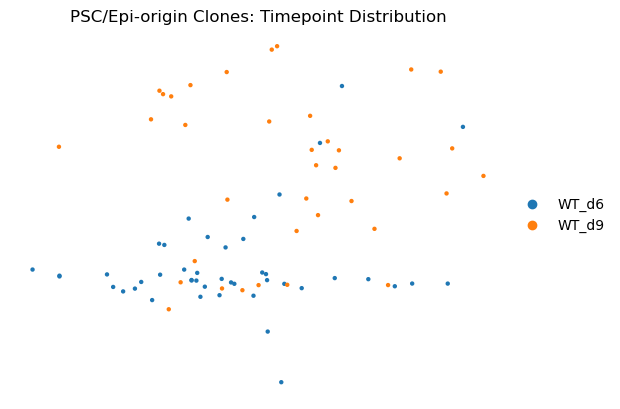

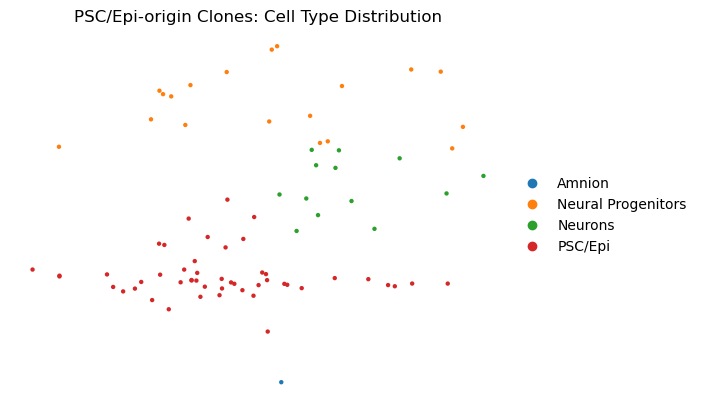

In [8]:
# Subset to only WT_d6 and WT_d9 samples
adata_wt = adata_combined[adata_combined.obs['sample'].isin(['WT_d6', 'WT_d9'])].copy()

# Step 1: Identify clones that are present in PSC/Epi cells at WT_d6
adata_psc_epi_d6 = adata_wt[(adata_wt.obs['sample'] == 'WT_d6') & (adata_wt.obs['celltype_v2'] == 'PSC/Epi')].copy()
psc_epi_d6_clones = adata_psc_epi_d6.obs['larry_clone'].unique()

print(f"Number of unique clones in WT_d6 PSC/Epi cells: {len(psc_epi_d6_clones)}")
print(f"Total PSC/Epi cells in WT_d6: {adata_psc_epi_d6.shape[0]}")

# Step 2: Among these clones, identify which persist in WT_d9 (across any cell type)
clone_sample_presence = adata_wt.obs[adata_wt.obs['larry_clone'].isin(psc_epi_d6_clones)].groupby('larry_clone')['sample'].unique()
persistent_psc_origin_clones = [clone for clone, samples in clone_sample_presence.items() 
                               if ('WT_d6' in samples) and ('WT_d9' in samples)]

print(f"\nNumber of PSC/Epi-origin clones that persist to WT_d9: {len(persistent_psc_origin_clones)}")

if len(persistent_psc_origin_clones) > 0:
    # Get the most abundant persistent clones from PSC/Epi origin
    persistent_clone_counts = adata_wt.obs[adata_wt.obs['larry_clone'].isin(persistent_psc_origin_clones)]['larry_clone'].value_counts()
    
    # Show all persistent clones if less than 20, otherwise top 20
    n_clones_to_show = min(29, len(persistent_clone_counts))
    top_persistent_clones = persistent_clone_counts.head(n_clones_to_show).index.tolist()
    
    print(f"\nTop {n_clones_to_show} most abundant persistent clones (PSC/Epi origin):")
    for i, (clone_id, count) in enumerate(persistent_clone_counts.head(n_clones_to_show).items()):
        # Count cells in each timepoint and initial cell type
        clone_d6_total = adata_wt[(adata_wt.obs['larry_clone'] == clone_id) & (adata_wt.obs['sample'] == 'WT_d6')].shape[0]
        clone_d9_total = adata_wt[(adata_wt.obs['larry_clone'] == clone_id) & (adata_wt.obs['sample'] == 'WT_d9')].shape[0]
        clone_psc_epi_d6 = adata_psc_epi_d6[adata_psc_epi_d6.obs['larry_clone'] == clone_id].shape[0]
        
        print(f"{i+1}. {clone_id}: {count} total cells")
        print(f"   - WT_d6: {clone_d6_total} cells ({clone_psc_epi_d6} in PSC/Epi)")
        print(f"   - WT_d9: {clone_d9_total} cells")
    
    # Create subset with these persistent clones across all cell types
    adata_persistent_tracking = adata_wt[adata_wt.obs['larry_clone'].isin(top_persistent_clones)].copy()

    # Plot 1: Color by sample (WT_d6 vs WT_d9)
    sc.pl.umap(adata_persistent_tracking, color='sample', show=False, frameon=False,
               size=40, title='PSC/Epi-origin Clones: Timepoint Distribution',
               palette=['#1f77b4', '#ff7f0e'])  # Blue for d6, Orange for d9

    # Plot 2: Color by cell type to see differentiation potential
    sc.pl.umap(adata_persistent_tracking, color='celltype_v2', show=False, frameon=False,
               size=40, title='PSC/Epi-origin Clones: Cell Type Distribution')

In [9]:
#NEW: Create tracking labels in the original adata_combined
# Initialize tracking column
adata_combined.obs['clone_tracking'] = 'Other'

# Mark PSC/Epi-Start: WT_d6 PSC/Epi cells from persistent clones
psc_start_mask = (
    (adata_combined.obs['sample'] == 'WT_d6') & 
    (adata_combined.obs['celltype_v2'] == 'PSC/Epi') & 
    (adata_combined.obs['larry_clone'].isin(top_persistent_clones))
)
adata_combined.obs.loc[psc_start_mask, 'clone_tracking'] = 'PSC/Epi-Start'

# Mark End: WT_d9 cells from persistent clones
end_mask = (
    (adata_combined.obs['sample'] == 'WT_d9') & 
    (adata_combined.obs['larry_clone'].isin(top_persistent_clones))
)
adata_combined.obs.loc[end_mask, 'clone_tracking'] = 'End'

print(f"\nTracking summary:")
print(adata_combined.obs['clone_tracking'].value_counts())


Tracking summary:
clone_tracking
Other            47527
PSC/Epi-Start       40
End                 37
Name: count, dtype: int64


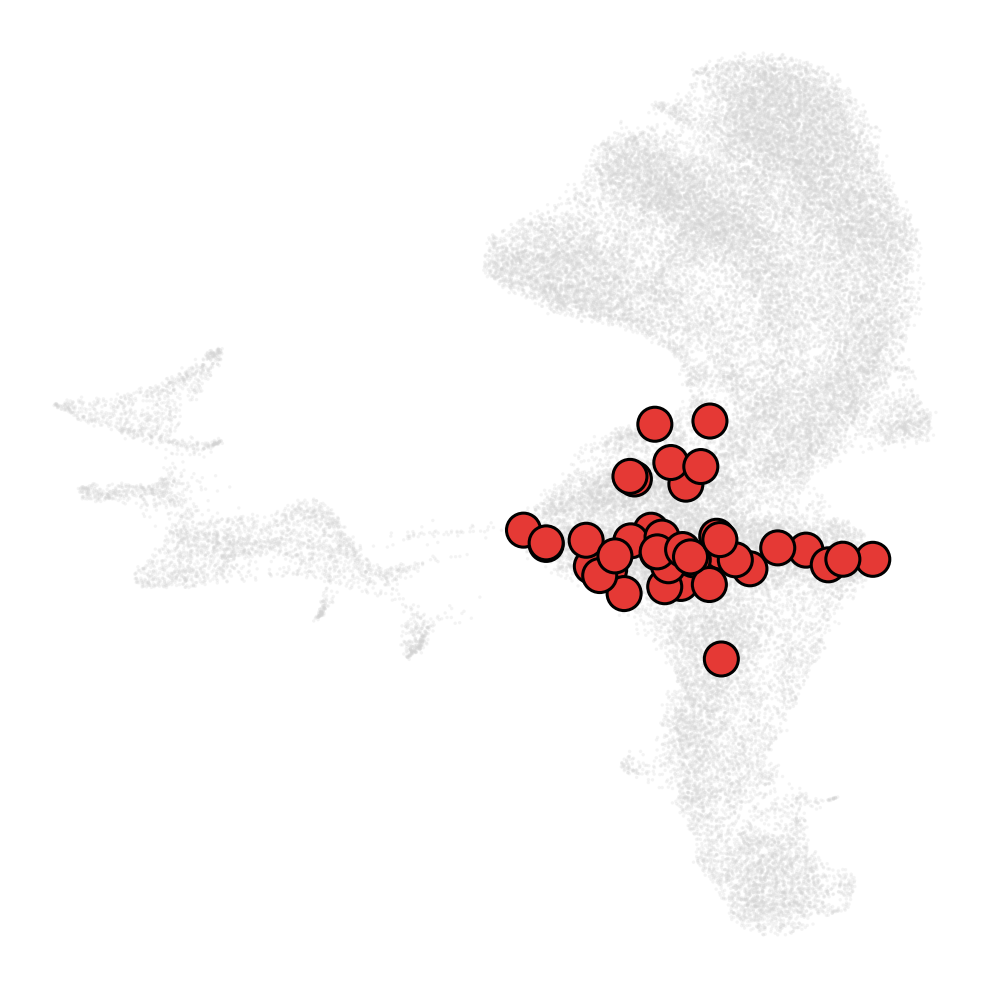

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# WT_d6 Start tracking cells colored by celltype_v2
# =========================================================

# your warm slightly desaturated palette
palette = [
    "#6BAED6", "#4DB6AC", "#74C476", "#A1D99B",
    "#FDD835", "#FDAE6B", "#F46D43", "#E53935",
    "#D81B60", "#8E24AA", "#9575CD", "#BDBDBD"
]

# Ensure consistent category order
adata_combined.obs["celltype_v2"] = adata_combined.obs["celltype_v2"].astype("category")
celltype_order = list(adata_combined.obs["celltype_v2"].cat.categories)

# Assign palette aligned to category order
adata_combined.uns["celltype_v2_colors"] = palette[:len(celltype_order)]
ct_color_map = dict(zip(celltype_order, adata_combined.uns["celltype_v2_colors"]))

# --- Select WT_d6 Start cells ---
mask_start = (
    (adata_combined.obs["clone_tracking"] == "PSC/Epi-Start") &
    (adata_combined.obs["sample"] == "WT_d6")
)

# UMAP coordinates
umap = adata_combined.obsm["X_umap"]

# Map celltype colors
start_ct = adata_combined.obs.loc[mask_start, "celltype_v2"].astype(str)
start_colors = start_ct.map(ct_color_map).values

# --- Plot ---
plt.figure(figsize=(10, 10))

# Background cells
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="#D3D3D3", s=6, alpha=0.25,
    edgecolors="none", zorder=1
)

# Highlight Start cells colored by cluster
plt.scatter(
    umap[mask_start, 0], umap[mask_start, 1],
    c=start_colors,
    s=600,
    edgecolors="black",
    linewidths=2.2,
    alpha=1.0,
    zorder=3
)

# Clean axes
ax = plt.gca()
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("WT_d6_Start_tracking_byCelltypeV2.tiff",
            dpi=600, format="tiff", bbox_inches="tight")
plt.show()

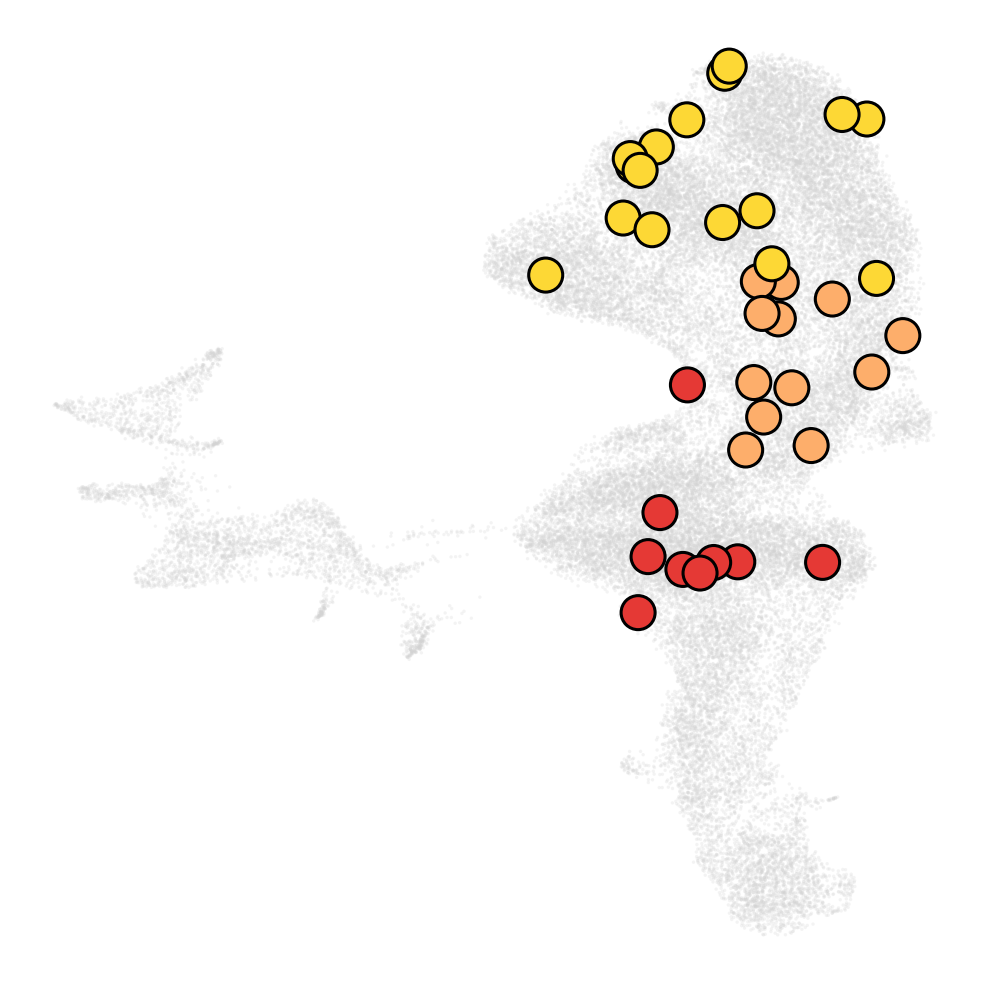

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# WT_d9 End tracking cells colored by *celltype_v2* (your palette)
# keeps background grey, only highlighted cells are colored
# =========================================================

# warm, slightly desaturated palette (your current one)
palette = [
    "#6BAED6", "#4DB6AC", "#74C476", "#A1D99B",
    "#FDD835", "#FDAE6B", "#F46D43", "#E53935",
    "#D81B60", "#8E24AA", "#9575CD", "#BDBDBD"
]

# --- Make sure category order is fixed and palette mapping is consistent ---
adata_combined.obs["celltype_v2"] = adata_combined.obs["celltype_v2"].astype("category")
celltype_order = list(adata_combined.obs["celltype_v2"].cat.categories)

# assign colors to the AnnData object (Scanpy-style: aligned to category order)
adata_combined.uns["celltype_v2_colors"] = palette[:len(celltype_order)]
ct_color_map = dict(zip(celltype_order, adata_combined.uns["celltype_v2_colors"]))

# --- Select the cells you want to highlight ---
mask_end = (
    (adata_combined.obs["clone_tracking"] == "End") &
    (adata_combined.obs["sample"] == "WT_d9")
)

# --- Pull UMAP coords ---
umap = adata_combined.obsm["X_umap"]

# --- Colors for highlighted cells (by their celltype_v2) ---
end_ct = adata_combined.obs.loc[mask_end, "celltype_v2"].astype(str)
end_colors = end_ct.map(ct_color_map).values

# --- Plot ---
plt.figure(figsize=(10, 10))

# background: all cells in light grey
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="#D3D3D3", s=6, alpha=0.25,
    edgecolors="none", zorder=1
)

# overlay: End cells colored by cluster
plt.scatter(
    umap[mask_end, 0], umap[mask_end, 1],
    c=end_colors,
    s=600,                 # adjust if you want bigger/smaller
    edgecolors="black",
    linewidths=2.2,
    alpha=1.0,
    zorder=3
)

# clean axes
ax = plt.gca()
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("WT_d9_End_tracking_byCelltypeV2.tiff",
            dpi=600, format="tiff", bbox_inches="tight")
plt.show()

In [22]:
# Fate distribution of PSC/Epi origin cells at WT D9
# Subset to WT_d9 End cells only
adata_d9_end = adata_combined[
    (adata_combined.obs["clone_tracking"] == "End") &
    (adata_combined.obs["sample"] == "WT_d9")
].copy()

# ---- Absolute counts ----
counts = adata_d9_end.obs["celltype_v2"].value_counts()
print("Absolute cell numbers per cluster:")
print(counts)

# ---- Percentages ----
percentages = counts / counts.sum() * 100
print("\nPercentage per cluster:")
print(percentages.round(2))

Absolute cell numbers per cluster:
celltype_v2
Neural Progenitors    16
Neurons               12
PSC/Epi                9
Name: count, dtype: int64

Percentage per cluster:
celltype_v2
Neural Progenitors    43.24
Neurons               32.43
PSC/Epi               24.32
Name: count, dtype: float64


In [23]:
import pandas as pd

# -------------------------------
# WT_d9: PSC/Epi-origin contribution + within-lineage fate
# -------------------------------

obs = adata_combined.obs

# All WT_d9 cells
wt_d9 = obs[obs["sample"] == "WT_d9"]

# PSC/Epi-origin tracked End cells at WT_d9
wt_d9_end = obs[(obs["sample"] == "WT_d9") & (obs["clone_tracking"] == "End")]

# Denominator: total WT_d9 cells per cluster
total_by_ct = wt_d9["celltype_v2"].value_counts()

# Numerator: PSC/Epi-origin End cells per cluster
end_by_ct = wt_d9_end["celltype_v2"].value_counts()

# Combine
df = pd.DataFrame({
    "PSC_origin_End_cells": end_by_ct,
    "Total_WT_d9_cells": total_by_ct
}).fillna(0)

# Contribution: PSC-origin / total cells in that cluster
df["PSC_origin_fraction_%"] = (df["PSC_origin_End_cells"] / df["Total_WT_d9_cells"] * 100)

# Keep only clusters PSC/Epi-origin cells actually go to
df = df[df["PSC_origin_End_cells"] > 0].copy()

# Within-lineage fate: this cluster / total PSC-origin End cells
total_end_cells = wt_d9_end.shape[0]
df["Within_PSC_origin_fate_%"] = (df["PSC_origin_End_cells"] / total_end_cells * 100)

# Formatting
df["PSC_origin_End_cells"] = df["PSC_origin_End_cells"].astype(int)
df["Total_WT_d9_cells"] = df["Total_WT_d9_cells"].astype(int)
df["PSC_origin_fraction_%"] = df["PSC_origin_fraction_%"].round(2)
df["Within_PSC_origin_fate_%"] = df["Within_PSC_origin_fate_%"].round(2)

# Sort (pick one; here: sort by within-lineage fate)
df = df.sort_values("Within_PSC_origin_fate_%", ascending=False)

df

,PSC_origin_End_cells,Total_WT_d9_cells,PSC_origin_fraction_%,Within_PSC_origin_fate_%
celltype_v2,,,,
Neural Progenitors,16,11140,0.14,43.24
Neurons,12,3594,0.33,32.43
PSC/Epi,9,1902,0.47,24.32


Number of unique clones in KO_d6 PSC/Epi cells: 4113
Total PSC/Epi cells in KO_d6: 6338

Number of PSC/Epi-origin clones that persist to KO_d9: 9

Top 29 most abundant persistent clones (PSC/Epi origin):
1. clone_26252: 5 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 4 cells
2. clone_22465: 4 total cells
   - KO_d6: 3 cells (2 in PSC/Epi)
   - KO_d9: 1 cells
3. clone_22805: 3 total cells
   - KO_d6: 2 cells (2 in PSC/Epi)
   - KO_d9: 1 cells
4. clone_26414: 3 total cells
   - KO_d6: 2 cells (2 in PSC/Epi)
   - KO_d9: 1 cells
5. clone_22097: 2 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 1 cells
6. clone_24869: 2 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 1 cells
7. clone_24530: 2 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 1 cells
8. clone_23119: 2 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 1 cells
9. clone_23228: 2 total cells
   - KO_d6: 1 cells (1 in PSC/Epi)
   - KO_d9: 1 cells
10. clone_26827: 0 total cells


/var/folders/dn/671y9yt10ljcw75jpbh0p5qh0000gn/T/ipykernel_5654/1507419833.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  clone_sample_presence = adata_KO.obs[adata_KO.obs['larry_clone'].isin(psc_epi_d6_clones)].groupby('larry_clone')['sample'].unique()


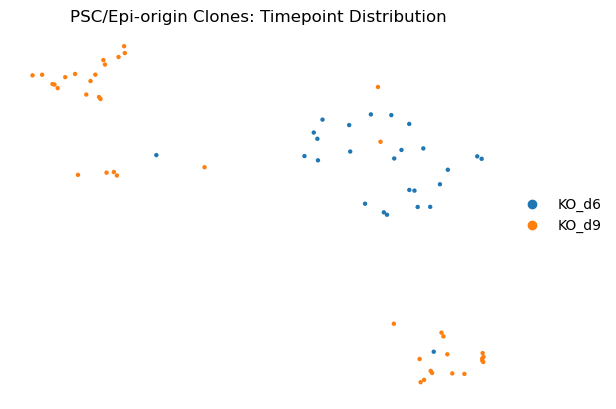

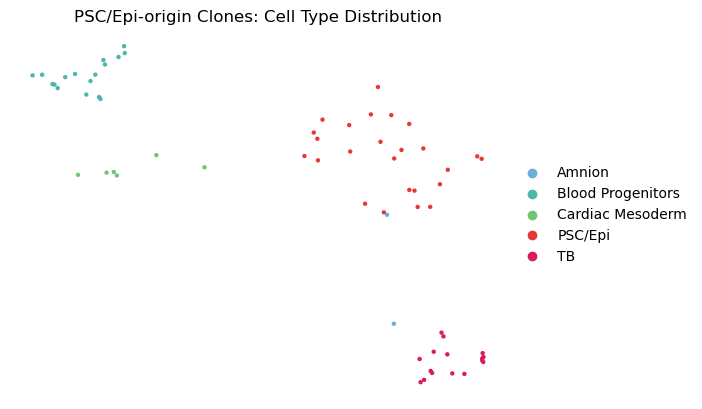

In [12]:
#For KO group


# Subset to only KO_d6 and KO_d9 samples
adata_KO = adata_combined[adata_combined.obs['sample'].isin(['KO_d6', 'KO_d9'])].copy()

# Step 1: Identify clones that are present in PSC/Epi cells at KO_d6
adata_psc_epi_d6 = adata_KO[(adata_KO.obs['sample'] == 'KO_d6') & (adata_KO.obs['celltype_v2'] == 'PSC/Epi')].copy()
psc_epi_d6_clones = adata_psc_epi_d6.obs['larry_clone'].unique()

print(f"Number of unique clones in KO_d6 PSC/Epi cells: {len(psc_epi_d6_clones)}")
print(f"Total PSC/Epi cells in KO_d6: {adata_psc_epi_d6.shape[0]}")

# Step 2: Among these clones, identify which persist in KO_d9 (across any cell type)
clone_sample_presence = adata_KO.obs[adata_KO.obs['larry_clone'].isin(psc_epi_d6_clones)].groupby('larry_clone')['sample'].unique()
persistent_psc_origin_clones = [clone for clone, samples in clone_sample_presence.items() 
                               if ('KO_d6' in samples) and ('KO_d9' in samples)]

print(f"\nNumber of PSC/Epi-origin clones that persist to KO_d9: {len(persistent_psc_origin_clones)}")

if len(persistent_psc_origin_clones) > 0:
    # Get the most abundant persistent clones from PSC/Epi origin
    persistent_clone_counts = adata_KO.obs[adata_KO.obs['larry_clone'].isin(persistent_psc_origin_clones)]['larry_clone'].value_counts()
    
    # Show all persistent clones if less than 20, otherwise top 20
    n_clones_to_show = min(29, len(persistent_clone_counts))
    top_persistent_clones = persistent_clone_counts.head(n_clones_to_show).index.tolist()
    
    print(f"\nTop {n_clones_to_show} most abundant persistent clones (PSC/Epi origin):")
    for i, (clone_id, count) in enumerate(persistent_clone_counts.head(n_clones_to_show).items()):
        # Count cells in each timepoint and initial cell type
        clone_d6_total = adata_KO[(adata_KO.obs['larry_clone'] == clone_id) & (adata_KO.obs['sample'] == 'KO_d6')].shape[0]
        clone_d9_total = adata_KO[(adata_KO.obs['larry_clone'] == clone_id) & (adata_KO.obs['sample'] == 'KO_d9')].shape[0]
        clone_psc_epi_d6 = adata_psc_epi_d6[adata_psc_epi_d6.obs['larry_clone'] == clone_id].shape[0]
        
        print(f"{i+1}. {clone_id}: {count} total cells")
        print(f"   - KO_d6: {clone_d6_total} cells ({clone_psc_epi_d6} in PSC/Epi)")
        print(f"   - KO_d9: {clone_d9_total} cells")
    
    # Create subset with these persistent clones across all cell types
    adata_persistent_tracking = adata_KO[adata_KO.obs['larry_clone'].isin(top_persistent_clones)].copy()

    # Plot 1: Color by sample (KO_d6 vs KO_d9)
    sc.pl.umap(adata_persistent_tracking, color='sample', show=False, frameon=False,
               size=40, title='PSC/Epi-origin Clones: Timepoint Distribution',
               palette=['#1f77b4', '#ff7f0e'])  # Blue for d6, Orange for d9

    # Plot 2: Color by cell type to see differentiation potential
    sc.pl.umap(adata_persistent_tracking, color='celltype_v2', show=False, frameon=False,
               size=40, title='PSC/Epi-origin Clones: Cell Type Distribution')


In [13]:
#NEW: Create tracking labels in the original adata_combined
# Initialize tracking column
adata_combined.obs['clone_tracking'] = 'Other'

# Mark PSC/Epi-Start: KO_d6 PSC/Epi cells from persistent clones
psc_start_mask = (
    (adata_combined.obs['sample'] == 'KO_d6') & 
    (adata_combined.obs['celltype_v2'] == 'PSC/Epi') & 
    (adata_combined.obs['larry_clone'].isin(top_persistent_clones))
)
adata_combined.obs.loc[psc_start_mask, 'clone_tracking'] = 'PSC/Epi-Start'

# Mark End: KO_d9 cells from persistent clones
end_mask = (
    (adata_combined.obs['sample'] == 'KO_d9') & 
    (adata_combined.obs['larry_clone'].isin(top_persistent_clones))
)
adata_combined.obs.loc[end_mask, 'clone_tracking'] = 'End'

print(f"\nTracking summary:")
print(adata_combined.obs['clone_tracking'].value_counts())



Tracking summary:
clone_tracking
Other            47541
End                 40
PSC/Epi-Start       23
Name: count, dtype: int64


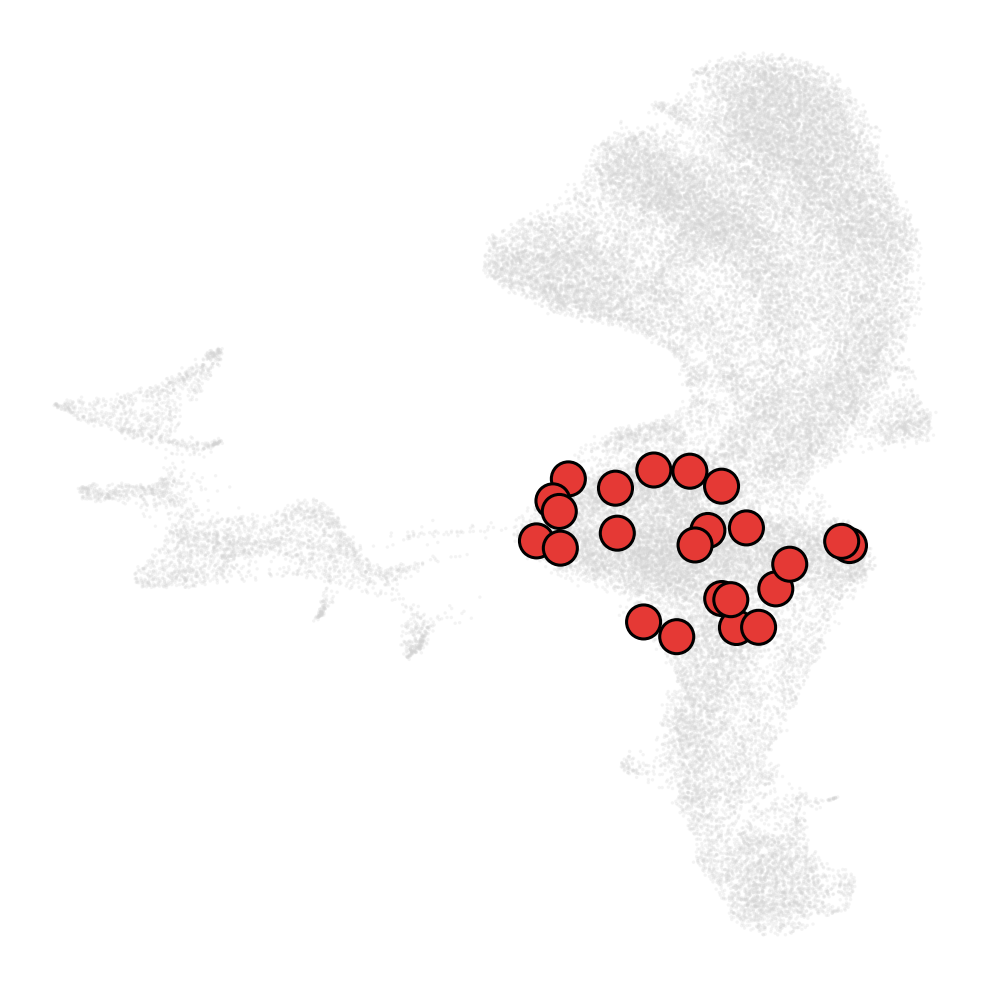

KO_d6 Start cells highlighted: 23


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# KO_d6 Start tracking cells colored by celltype_v2
# =========================================================

palette = [
    "#6BAED6", "#4DB6AC", "#74C476", "#A1D99B",
    "#FDD835", "#FDAE6B", "#F46D43", "#E53935",
    "#D81B60", "#8E24AA", "#9575CD", "#BDBDBD"
]

# Ensure consistent category order + colors
adata_combined.obs["celltype_v2"] = adata_combined.obs["celltype_v2"].astype("category")
celltype_order = list(adata_combined.obs["celltype_v2"].cat.categories)
adata_combined.uns["celltype_v2_colors"] = palette[:len(celltype_order)]
ct_color_map = dict(zip(celltype_order, adata_combined.uns["celltype_v2_colors"]))

# --- Select KO_d6 Start cells ---
mask_start = (
    (adata_combined.obs["clone_tracking"] == "PSC/Epi-Start") &
    (adata_combined.obs["sample"] == "KO_d6")
)

umap = adata_combined.obsm["X_umap"]

start_ct = adata_combined.obs.loc[mask_start, "celltype_v2"].astype(str)
start_colors = start_ct.map(ct_color_map).values

plt.figure(figsize=(10, 10))

# Background (all cells)
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="#D3D3D3", s=6, alpha=0.25,
    edgecolors="none", zorder=1
)

# Highlight Start cells colored by cluster
plt.scatter(
    umap[mask_start, 0], umap[mask_start, 1],
    c=start_colors,
    s=600,
    edgecolors="black",
    linewidths=2.2,
    alpha=1.0,
    zorder=3
)

# Clean axes
ax = plt.gca()
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("KO_d6_Start_tracking_byCelltypeV2.tiff",
            dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("KO_d6 Start cells highlighted:", int(mask_start.sum()))

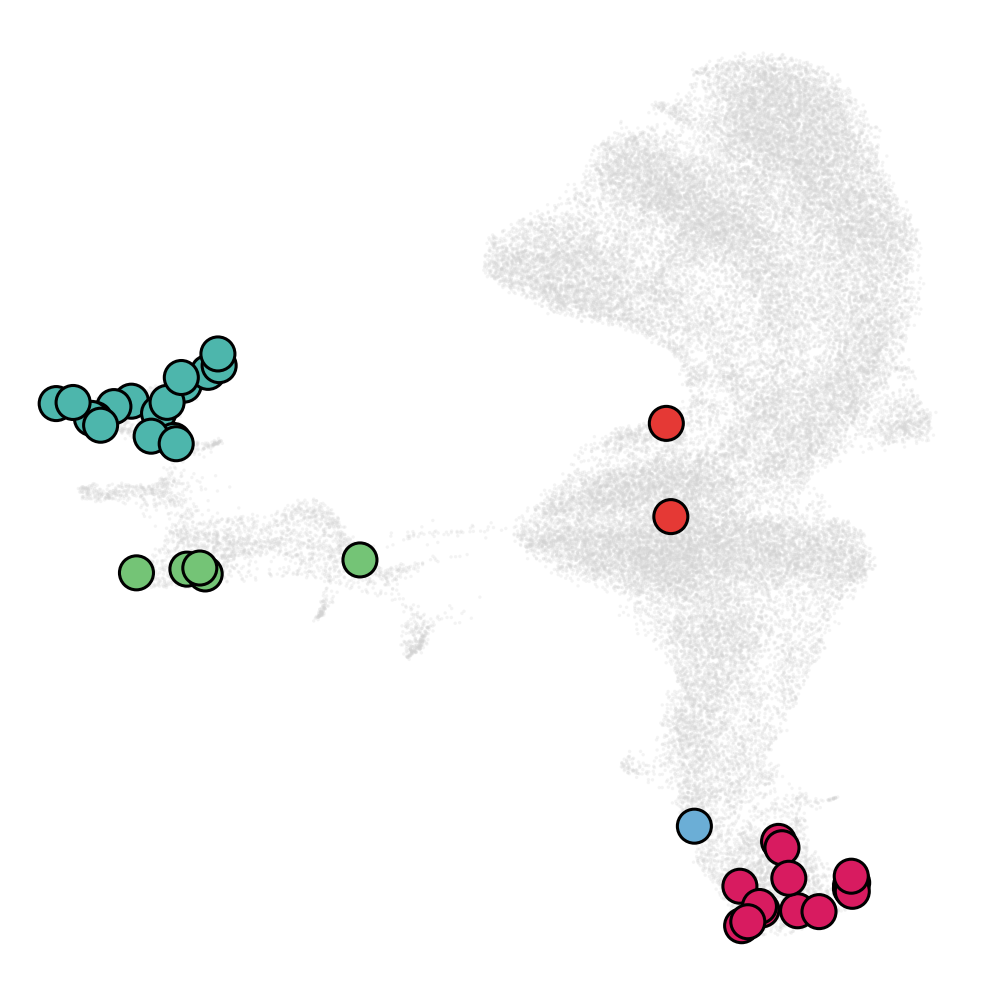

KO_d9 End cells highlighted: 40


In [15]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# KO_d9 End tracking cells colored by celltype_v2
# =========================================================

palette = [
"#6BAED6", "#4DB6AC", "#74C476", "#A1D99B",
"#FDD835", "#FDAE6B", "#F46D43", "#E53935",
"#D81B60", "#8E24AA", "#9575CD", "#BDBDBD"
]

# Ensure consistent category order
adata_combined.obs["celltype_v2"] = adata_combined.obs["celltype_v2"].astype("category")
celltype_order = list(adata_combined.obs["celltype_v2"].cat.categories)

adata_combined.uns["celltype_v2_colors"] = palette[:len(celltype_order)]
ct_color_map = dict(zip(celltype_order, adata_combined.uns["celltype_v2_colors"]))

# --- Select KO_d9 End cells ---
mask_end = (
    (adata_combined.obs["clone_tracking"] == "End") &
    (adata_combined.obs["sample"] == "KO_d9")
)

umap = adata_combined.obsm["X_umap"]

end_ct = adata_combined.obs.loc[mask_end, "celltype_v2"].astype(str)
end_colors = end_ct.map(ct_color_map).values

plt.figure(figsize=(10, 10))

# Background
plt.scatter(
    umap[:, 0], umap[:, 1],
    c="#D3D3D3", s=6, alpha=0.25,
    edgecolors="none", zorder=1
)

# Highlight End cells colored by cluster
plt.scatter(
    umap[mask_end, 0], umap[mask_end, 1],
    c=end_colors,
    s=600,
    edgecolors="black",
    linewidths=2.2,
    alpha=1.0,
    zorder=3
)

# Clean axes
ax = plt.gca()
ax.set_xticks([]); ax.set_yticks([])
ax.set_xlabel(""); ax.set_ylabel("")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.savefig("KO_d9_End_tracking_byCelltypeV2.tiff",
            dpi=600, format="tiff", bbox_inches="tight")
plt.show()

print("KO_d9 End cells highlighted:", int(mask_end.sum()))

In [34]:
import pandas as pd

# -------------------------------
# KO_d9: PSC/Epi-origin contribution + within-lineage fate
# -------------------------------

obs = adata_combined.obs

# All KO_d9 cells
ko_d9 = obs[obs["sample"] == "KO_d9"]

# PSC/Epi-origin tracked End cells at KO_d9
ko_d9_end = obs[
    (obs["sample"] == "KO_d9") &
    (obs["clone_tracking"] == "End")
]

# Denominator: total KO_d9 cells per cluster
total_by_ct = ko_d9["celltype_v2"].value_counts()

# Numerator: PSC-origin End cells per cluster
end_by_ct = ko_d9_end["celltype_v2"].value_counts()

# Combine
df_ko = pd.DataFrame({
    "PSC_origin_End_cells": end_by_ct,
    "Total_KO_d9_cells": total_by_ct
}).fillna(0)

# Contribution: PSC-origin / total cluster size
df_ko["PSC_origin_fraction_%"] = (
    df_ko["PSC_origin_End_cells"] /
    df_ko["Total_KO_d9_cells"] * 100
)

# Keep only clusters PSC-origin cells go to
df_ko = df_ko[df_ko["PSC_origin_End_cells"] > 0].copy()

# Within-lineage fate distribution
total_end_cells = ko_d9_end.shape[0]

df_ko["Within_PSC_origin_fate_%"] = (
    df_ko["PSC_origin_End_cells"] /
    total_end_cells * 100
)

# Formatting
df_ko["PSC_origin_End_cells"] = df_ko["PSC_origin_End_cells"].astype(int)
df_ko["Total_KO_d9_cells"] = df_ko["Total_KO_d9_cells"].astype(int)
df_ko["PSC_origin_fraction_%"] = df_ko["PSC_origin_fraction_%"].round(2)
df_ko["Within_PSC_origin_fate_%"] = df_ko["Within_PSC_origin_fate_%"].round(2)

df_ko = df_ko.sort_values("Within_PSC_origin_fate_%", ascending=False)

df_ko

,PSC_origin_End_cells,Total_KO_d9_cells,PSC_origin_fraction_%,Within_PSC_origin_fate_%
celltype_v2,,,,
Blood Progenitors,17,518,3.28,42.5
TB,15,1966,0.76,37.5
Cardiac Mesoderm,5,912,0.55,12.5
PSC/Epi,2,861,0.23,5.0
Amnion,1,579,0.17,2.5


In [38]:
# Table of data for R input
# Extract only fate percentages
wt_fate = df["Within_PSC_origin_fate_%"]
ko_fate = df_ko["Within_PSC_origin_fate_%"]

# Combine clusters from both
all_clusters = sorted(set(wt_fate.index).union(set(ko_fate.index)))

# Create clean percentage-only table
fate_table = pd.DataFrame({
    "Cluster": all_clusters,
    "WT_percent": [wt_fate.get(c, 0) for c in all_clusters],
    "KO_percent": [ko_fate.get(c, 0) for c in all_clusters]
})

fate_table

,Cluster,WT_percent,KO_percent
0,Amnion,0.00,2.5
1,Blood Progenitors,0.00,42.5
2,Cardiac Mesoderm,0.00,12.5
3,Neural Progenitors,43.24,0.0
4,Neurons,32.43,0.0
5,PSC/Epi,24.32,5.0
6,TB,0.00,37.5


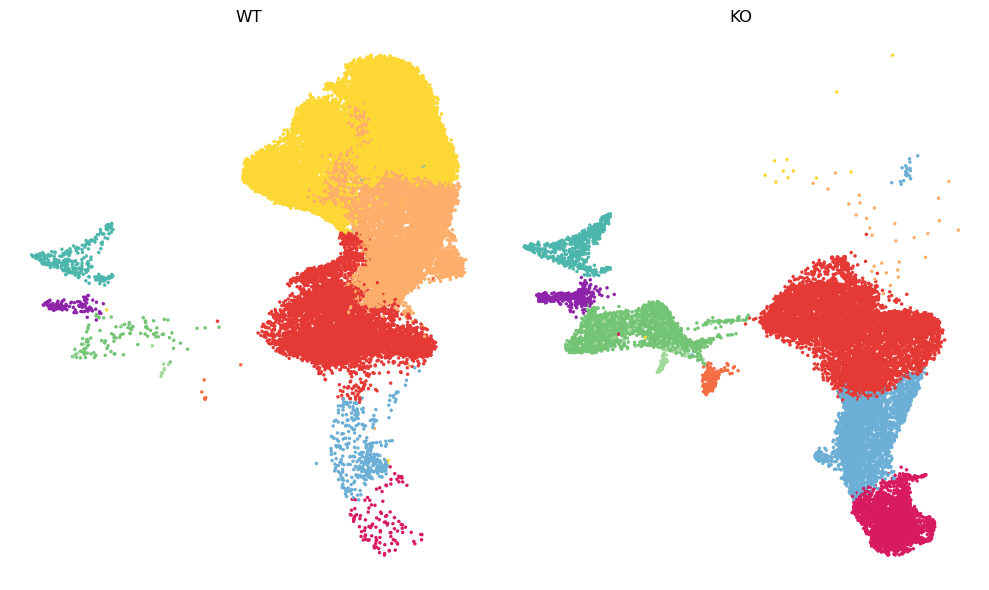

In [110]:
import matplotlib.pyplot as plt
import scanpy as sc

# Keep consistent colors
adata_wt.uns["celltype_v2_colors"] = adata_combined.uns["celltype_v2_colors"]
adata_ko.uns["celltype_v2_colors"] = adata_combined.uns["celltype_v2_colors"]

fig, axes = plt.subplots(1, 2, figsize=(10, 6))

# Define a new palette (example: softer, more publication-style)
import seaborn as sns
# Custom warm developmental atlas palette
palette = [
    "#6BAED6",  # soft blue
    "#4DB6AC",  # teal
    "#74C476",  # soft green
    "#A1D99B",  # light green
    "#FDD835",  # warm yellow
    "#FDAE6B",  # soft orange
    "#F46D43",  # coral
    "#E53935",  # red
    "#D81B60",  # pink-red
    "#8E24AA",  # muted purple
    "#9575CD",  # lavender
    "#BDBDBD"   # grey (if needed)
]

# Make sure length matches number of clusters
n_clusters = adata_combined.obs["celltype_v2"].nunique()
palette = palette[:n_clusters]
# OR try:
# palette = sc.pl.palettes.vega_20_scanpy

# WT
sc.pl.umap(
    adata_wt,
    color="celltype_v2",
    ax=axes[0],
    show=False,
    legend_loc=None,
    title="WT",
    frameon=False,
    size=25,              # 🔥 increase point size here
    palette=palette       # 🎨 change palette here
)

# KO
sc.pl.umap(
    adata_ko,
    color="celltype_v2",
    ax=axes[1],
    show=False,
    legend_loc=None,
    title="KO",
    frameon=False,
    size=25,              # same size
    palette=palette
)

plt.tight_layout()
plt.show()

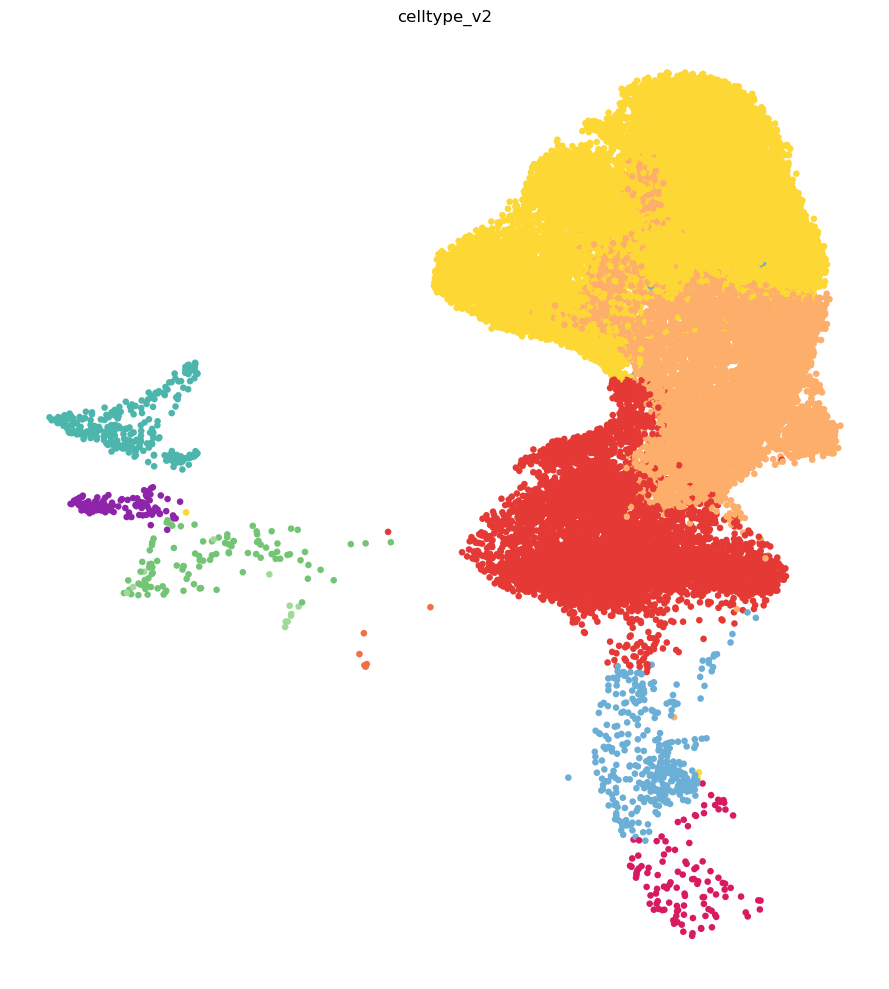

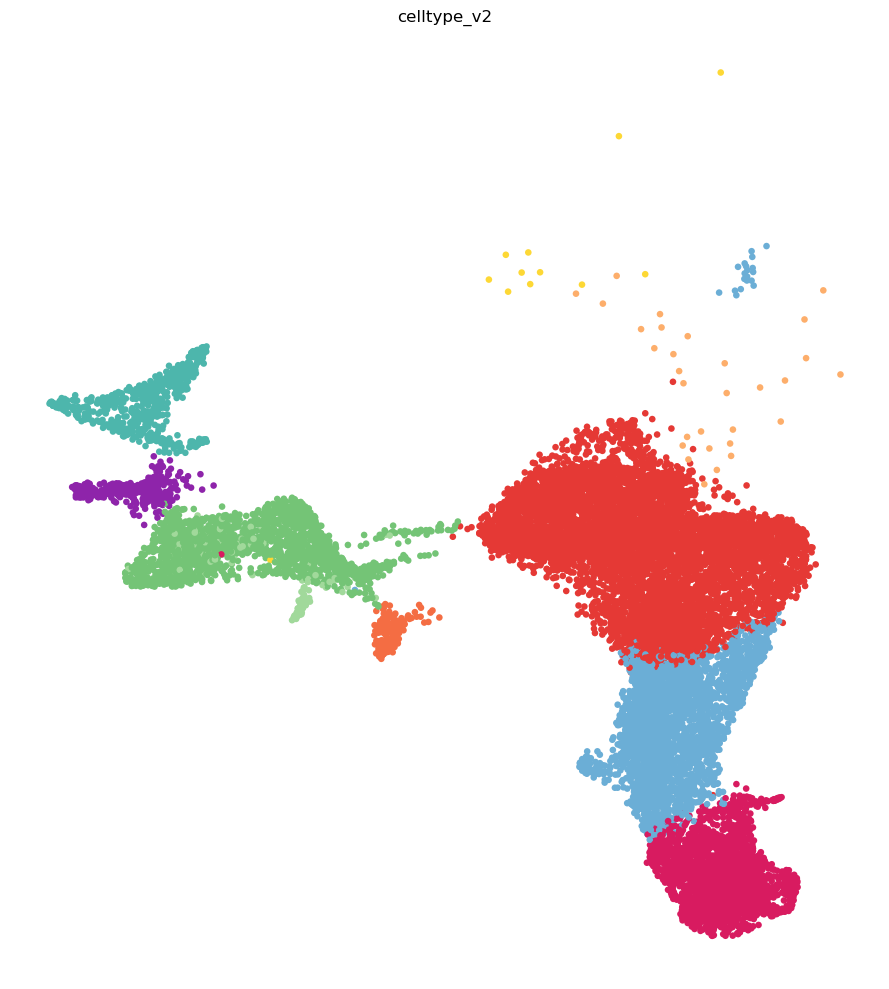

In [16]:
import matplotlib.pyplot as plt
import scanpy as sc

# keep consistent cluster colors between WT/KO
adata_wt.uns["celltype_v2_colors"] = adata_combined.uns["celltype_v2_colors"]
adata_ko.uns["celltype_v2_colors"] = adata_combined.uns["celltype_v2_colors"]

# warm, slightly desaturated palette (your current one)
palette = [
    "#6BAED6", "#4DB6AC", "#74C476", "#A1D99B",
    "#FDD835", "#FDAE6B", "#F46D43", "#E53935",
    "#D81B60", "#8E24AA", "#9575CD", "#BDBDBD"
]
n_clusters = adata_combined.obs["celltype_v2"].nunique()
palette = palette[:n_clusters]

POINT_SIZE = 90  # change if you want bigger

# --- WT plot ---
fig, ax = plt.subplots(figsize=(9, 10))  # ← THIS now controls size
sc.pl.umap(
    adata_wt,
    color="celltype_v2",
    legend_loc=None,
    title=None,
    frameon=False,
    size=POINT_SIZE,
    palette=palette,
    ax=ax, 
    show=False
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#B0B0B0")   # dark grey
    spine.set_linewidth(2)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "WT_UMAP_edit.tiff",
    format="tiff",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

# --- KO plot ---
fig, ax = plt.subplots(figsize=(9, 10))  # ← THIS now controls size
sc.pl.umap(
    adata_ko,
    color="celltype_v2",
    legend_loc=None,
    title=None,
    frameon=False,
    size=POINT_SIZE,
    palette=palette,
    ax=ax,
    show=False
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#B0B0B0")   # dark grey
    spine.set_linewidth(2)

ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.savefig(
    "KO_UMAP_edit.tiff",
    format="tiff",
    dpi=600,
    bbox_inches="tight"
)
plt.show()